# Klasyfikacja kierunku ceny akcji v2 (PyTorch)

Drugi notebook (v2) zostawia poprzedni bez zmian i testuje mocniejszy pipeline:
- tuning progu klasy `bez_zmian`,
- tuning zestawu lagow,
- reczna siec MLP w PyTorch (weighted loss + early stopping),
- walidacja czasowa (expanding window),
- finalny test na ostatnich 2 miesiacach.


In [1]:
from copy import deepcopy
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
TEST_MONTHS = 2
NEUTRAL_BANDS = [0.0025, 0.004, 0.006]
LAG_SCHEMES = {
    "short": [1, 2, 3, 5, 10],
    "extended": [1, 2, 3, 5, 10, 15, 20],
}
CV_FOLDS = 3
CV_VAL_SIZE = 40
CV_MIN_TRAIN = 260

MODEL_CFG = {
    "hidden": (256, 128, 64),
    "dropout": 0.35,
    "lr": 7e-4,
    "wd": 3e-4,
    "label_smoothing": 0.02,
    "batch": 64,
    "epochs": 220,
    "patience": 25,
}

CLASS_ORDER = ["spadek", "bez_zmian", "wzrost"]
CLASS_TO_CODE = {"spadek": 0, "bez_zmian": 1, "wzrost": 2}
CODE_TO_CLASS = {v: k for k, v in CLASS_TO_CODE.items()}
CLASS_CODE_ORDER = [CLASS_TO_CODE[c] for c in CLASS_ORDER]

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(RANDOM_STATE)
print("torch:", torch.__version__)


torch: 2.10.0


In [2]:
def locate_file(root, names):
    for n in names:
        p = root / n
        if p.exists():
            return p
    raise FileNotFoundError(names)

def read_daily_csv(path):
    df = pd.read_csv(path)
    date_col = "date" if "date" in df.columns else ("Date" if "Date" in df.columns else None)
    if date_col is None:
        raise ValueError(f"Brak daty: {path}")
    if date_col != "date":
        df = df.rename(columns={date_col: "date"})
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.dropna(subset=["date"]).sort_values("date").drop_duplicates("date", keep="last").reset_index(drop=True)
    for c in df.columns:
        if c != "date":
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def prefix(df, p):
    return df.rename(columns={c: f"{p}{c}" for c in df.columns if c != "date"})

def add_lags(frame, feature_cols, lags):
    parts = [frame]
    for lag in lags:
        sh = frame[feature_cols].shift(lag).rename(columns={c: f"{c}_lag{lag}" for c in feature_cols})
        parts.append(sh)
    return pd.concat(parts, axis=1)

def make_folds(train_df, n_folds=3, val_size=40, min_train=260):
    n = len(train_df)
    folds = []
    for i in range(n_folds):
        val_end = n - val_size * (n_folds - 1 - i)
        val_start = val_end - val_size
        if val_start < min_train:
            continue
        folds.append((np.arange(0, val_start), np.arange(val_start, val_end)))
    return folds

class TorchMLP(nn.Module):
    def __init__(self, inp, hidden=(256, 128, 64), dropout=0.35):
        super().__init__()
        layers = []
        prev = inp
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.BatchNorm1d(h), nn.Dropout(dropout)]
            prev = h
        layers += [nn.Linear(prev, 3)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

def fit_torch(X_tr, y_tr, X_val, y_val, cfg, seed=42, verbose=False):
    seed_everything(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    imp = SimpleImputer(strategy="median")
    X_tr = imp.fit_transform(X_tr)
    X_val = imp.transform(X_val)
    sc = StandardScaler()
    X_tr = sc.fit_transform(X_tr).astype(np.float32)
    X_val = sc.transform(X_val).astype(np.float32)
    y_tr = y_tr.astype(np.int64)
    y_val = y_val.astype(np.int64)

    counts = np.bincount(y_tr, minlength=3).astype(float)
    w = np.where(counts > 0, len(y_tr) / (3.0 * counts), 0.0)

    ds = TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr))
    dl = DataLoader(ds, batch_size=cfg["batch"], shuffle=True)

    model = TorchMLP(X_tr.shape[1], hidden=cfg["hidden"], dropout=cfg["dropout"]).to(device)
    loss_fn = nn.CrossEntropyLoss(
        weight=torch.tensor(w, dtype=torch.float32, device=device),
        label_smoothing=cfg["label_smoothing"],
    )
    opt = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=cfg["wd"])

    X_val_t = torch.from_numpy(X_val).to(device)
    best_score, best_epoch, best_state = -1e9, 0, None
    no_imp = 0
    for ep in range(1, cfg["epochs"] + 1):
        model.train()
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            out = model(xb)
            loss = loss_fn(out, yb)
            loss.backward()
            opt.step()
        model.eval()
        with torch.no_grad():
            pred = model(X_val_t).argmax(1).cpu().numpy()
        mf1 = f1_score(y_val, pred, average="macro", zero_division=0)
        bacc = balanced_accuracy_score(y_val, pred)
        score = 0.7 * mf1 + 0.3 * bacc
        if score > best_score + 1e-6:
            best_score, best_epoch, best_state = score, ep, deepcopy(model.state_dict())
            no_imp = 0
        else:
            no_imp += 1
        if no_imp >= cfg["patience"]:
            break
        if verbose and ep % 25 == 0:
            print(f"ep={ep} mf1={mf1:.4f} bacc={bacc:.4f} best_ep={best_epoch}")
    model.load_state_dict(best_state)
    return {"model": model, "imp": imp, "sc": sc, "device": device, "best_epoch": best_epoch}

def fit_torch_full(X_tr, y_tr, cfg, epochs, seed=42):
    seed_everything(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    imp = SimpleImputer(strategy="median")
    X_tr = imp.fit_transform(X_tr)
    sc = StandardScaler()
    X_tr = sc.fit_transform(X_tr).astype(np.float32)
    y_tr = y_tr.astype(np.int64)
    counts = np.bincount(y_tr, minlength=3).astype(float)
    w = np.where(counts > 0, len(y_tr) / (3.0 * counts), 0.0)
    ds = TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr))
    dl = DataLoader(ds, batch_size=cfg["batch"], shuffle=True)
    model = TorchMLP(X_tr.shape[1], hidden=cfg["hidden"], dropout=cfg["dropout"]).to(device)
    loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(w, dtype=torch.float32, device=device), label_smoothing=cfg["label_smoothing"])
    opt = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=cfg["wd"])
    for _ in range(int(epochs)):
        model.train()
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            out = model(xb)
            loss = loss_fn(out, yb)
            loss.backward()
            opt.step()
    model.eval()
    return {"model": model, "imp": imp, "sc": sc, "device": device}

def predict_torch(bundle, X):
    X = bundle["imp"].transform(X)
    X = bundle["sc"].transform(X).astype(np.float32)
    Xt = torch.from_numpy(X).to(bundle["device"])
    bundle["model"].eval()
    with torch.no_grad():
        return bundle["model"](Xt).argmax(1).cpu().numpy().astype(np.int64)


In [3]:
data_root = next((p for p in [Path("../data/equity_data"), Path("data/equity_data")] if p.exists()), None)
if data_root is None:
    raise FileNotFoundError("Brak data/equity_data")
output_dir = data_root / "model_data"
output_dir.mkdir(parents=True, exist_ok=True)

stock = read_daily_csv(locate_file(data_root, ["stock-prices-data.csv"]))
subm = prefix(read_daily_csv(locate_file(data_root, ["stock-reddit-data.csv"])), "subm_")
comm = prefix(read_daily_csv(locate_file(data_root, ["stock-reddit-comments-data.csv", "stock-reddit-comments-data"])), "comm_")
trends = read_daily_csv(locate_file(data_root, ["google_trends_data.csv"]))
trends = trends.rename(columns={"trends_score": "google_trends_score"})
gdelt = read_daily_csv(locate_file(data_root, ["gdelt_data_faily_filled.csv", "gdelt_data_dailt_filled.csv", "gdelt_data_daily_filled.csv", "gdelt_data.csv"]))
if "sentiment_score" in gdelt.columns:
    gdelt = gdelt.rename(columns={"sentiment_score": "gdelt_sentiment_score"})

merged = stock.merge(subm, on="date", how="left").merge(comm, on="date", how="left").merge(trends, on="date", how="left").merge(gdelt, on="date", how="left")
merged = merged.sort_values("date").reset_index(drop=True)

for c in ["google_trends_score", "gdelt_articles", "gdelt_sentiment_score"]:
    if c in merged.columns:
        merged[c] = merged[c].ffill().bfill()

merged["stock_return_1d"] = merged["stock_price"].pct_change(1)
merged["stock_return_2d"] = merged["stock_price"].pct_change(2)
merged["stock_return_5d"] = merged["stock_price"].pct_change(5)
merged["stock_return_10d"] = merged["stock_price"].pct_change(10)
merged["stock_volume_change_1d"] = merged["stock_volume"].pct_change(1)
merged["stock_volume_change_5d"] = merged["stock_volume"].pct_change(5)
merged["realized_vol_5d"] = merged["stock_return_1d"].rolling(5).std()
merged["realized_vol_10d"] = merged["stock_return_1d"].rolling(10).std()
merged["price_vs_sma_5d"] = merged["stock_price"] / merged["stock_price"].rolling(5).mean() - 1
merged["price_vs_sma_10d"] = merged["stock_price"] / merged["stock_price"].rolling(10).mean() - 1
merged["weekday"] = merged["date"].dt.dayofweek.astype(float)
if "google_trends_score" in merged.columns:
    merged["trends_change_1d"] = merged["google_trends_score"].pct_change(1)
    merged["trends_change_7d"] = merged["google_trends_score"].pct_change(7)
if "gdelt_articles" in merged.columns:
    merged["gdelt_articles_change_1d"] = merged["gdelt_articles"].pct_change(1)
if "gdelt_sentiment_score" in merged.columns:
    merged["gdelt_sentiment_5d"] = merged["gdelt_sentiment_score"].rolling(5).mean()

def reddit_feats(df, p):
    cols = [f"{p}reddit_posts", f"{p}reddit_score_sum", f"{p}reddit_comments_sum", f"{p}reddit_weight_sum", f"{p}reddit_vader_mean", f"{p}reddit_finbert_mean", f"{p}reddit_vader_weighted_mean", f"{p}reddit_finbert_weighted_mean"]
    for c in cols:
        if c in df.columns:
            df[c] = df[c].fillna(0)
    out = [c for c in cols if c in df.columns]
    posts = f"{p}reddit_posts"
    if posts in df.columns:
        df[f"{p}active_flag"] = (df[posts] > 0).astype(float)
        out += [f"{p}active_flag"]
    if posts in df.columns and f"{p}reddit_score_sum" in df.columns:
        df[f"{p}score_per_post"] = (df[f"{p}reddit_score_sum"] / df[posts].replace(0, np.nan)).fillna(0)
        out += [f"{p}score_per_post"]
    if posts in df.columns and f"{p}reddit_comments_sum" in df.columns:
        df[f"{p}comments_per_post"] = (df[f"{p}reddit_comments_sum"] / df[posts].replace(0, np.nan)).fillna(0)
        out += [f"{p}comments_per_post"]
    if f"{p}reddit_vader_mean" in df.columns and f"{p}reddit_finbert_mean" in df.columns:
        df[f"{p}sent_gap_mean"] = (df[f"{p}reddit_vader_mean"] - df[f"{p}reddit_finbert_mean"]).abs()
        out += [f"{p}sent_gap_mean"]
    return out

base_features = [
    "stock_price", "stock_volume", "stock_return_1d", "stock_return_2d", "stock_return_5d", "stock_return_10d",
    "stock_volume_change_1d", "stock_volume_change_5d", "realized_vol_5d", "realized_vol_10d", "price_vs_sma_5d", "price_vs_sma_10d", "weekday",
    "google_trends_score", "trends_change_1d", "trends_change_7d", "gdelt_articles", "gdelt_articles_change_1d", "gdelt_sentiment_score", "gdelt_sentiment_5d"
]
base_features += reddit_feats(merged, "subm_")
base_features += reddit_feats(merged, "comm_")
base_features = [c for c in dict.fromkeys(base_features) if c in merged.columns]
base_df = merged[["date"] + base_features].copy()

print(f"rows={len(base_df):,} | base_features={len(base_features)} | zakres={base_df['date'].min().date()} -> {base_df['date'].max().date()}")
display(base_df.head())


rows=752 | base_features=44 | zakres=2023-01-03 -> 2025-12-31


,date,stock_price,stock_volume,stock_return_1d,stock_return_2d,stock_return_5d,stock_return_10d,stock_volume_change_1d,stock_volume_change_5d,realized_vol_5d,...,comm_reddit_comments_sum,comm_reddit_weight_sum,comm_reddit_vader_mean,comm_reddit_finbert_mean,comm_reddit_vader_weighted_mean,comm_reddit_finbert_weighted_mean,comm_active_flag,comm_score_per_post,comm_comments_per_post,comm_sent_gap_mean
0,2023-01-03,108.099998,231402800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,956.997338,0.189132,-0.126214,0.187674,-0.137697,1.0,4.450331,0.0,0.315346
1,2023-01-04,113.639999,180389000,0.051249,NaN,NaN,NaN,-0.220455,NaN,NaN,...,0.0,401.176009,0.166106,-0.115101,0.133119,-0.107439,1.0,6.445783,0.0,0.281207
2,2023-01-05,110.339996,157986300,-0.029039,0.020722,NaN,NaN,-0.124191,NaN,NaN,...,0.0,175.981376,0.178694,-0.050430,0.126862,-0.062067,1.0,27.657143,0.0,0.229124
3,2023-01-06,113.059998,220911100,0.024651,-0.005104,NaN,NaN,0.398293,NaN,NaN,...,0.0,162.583013,0.285260,-0.188127,0.279178,-0.245605,1.0,8.253731,0.0,0.473386
4,2023-01-09,119.769997,190284000,0.059349,0.085463,NaN,NaN,-0.138640,NaN,NaN,...,0.0,272.903966,0.194505,-0.137947,0.193804,-0.139227,1.0,2.000000,0.0,0.332452


In [4]:
def build_dataset(base_df, feature_cols, neutral_band, lags):
    ds = base_df.copy()
    ds["future_return_1d"] = ds["stock_price"].shift(-1) / ds["stock_price"] - 1
    y = np.full(len(ds), -1, dtype=np.int64)
    y[ds["future_return_1d"] < -neutral_band] = 0
    y[ds["future_return_1d"].abs() <= neutral_band] = 1
    y[ds["future_return_1d"] > neutral_band] = 2
    ds["y_code"] = y
    ds["y"] = pd.Series(y).map(CODE_TO_CLASS)
    ds = ds[ds["y_code"] >= 0].copy().reset_index(drop=True)
    core = ds[["date", "future_return_1d", "y", "y_code"] + feature_cols].copy()
    lagged = add_lags(core, feature_cols, lags)
    lagged = lagged.dropna(subset=["y_code"]).reset_index(drop=True)
    feat_cols = [c for c in lagged.columns if c not in ["date", "future_return_1d", "y", "y_code"]]
    return ds, lagged, feat_cols

rows = []
cache = {}
for nb in NEUTRAL_BANDS:
    for lag_name, lags in LAG_SCHEMES.items():
        base_ds, lagged_ds, feat_cols = build_dataset(base_df, base_features, float(nb), list(lags))
        test_start = (lagged_ds["date"].max() - pd.DateOffset(months=TEST_MONTHS)).normalize()
        train_df = lagged_ds[lagged_ds["date"] < test_start].copy()
        test_df = lagged_ds[lagged_ds["date"] >= test_start].copy()
        if train_df.empty or test_df.empty:
            continue
        folds = make_folds(train_df, CV_FOLDS, CV_VAL_SIZE, CV_MIN_TRAIN)
        if not folds:
            continue
        mf1_list, bacc_list, epoch_list = [], [], []
        print(f"CV nb={nb:.4f}, lag={lag_name}, features={len(feat_cols)}")
        for fid, (tr_idx, val_idx) in enumerate(folds, 1):
            tr = train_df.iloc[tr_idx]
            va = train_df.iloc[val_idx]
            bundle = fit_torch(tr[feat_cols], tr["y_code"].to_numpy(), va[feat_cols], va["y_code"].to_numpy(), MODEL_CFG, seed=RANDOM_STATE + fid)
            pred = predict_torch(bundle, va[feat_cols])
            mf1 = f1_score(va["y_code"].to_numpy(), pred, average="macro", zero_division=0)
            bacc = balanced_accuracy_score(va["y_code"].to_numpy(), pred)
            mf1_list.append(mf1)
            bacc_list.append(bacc)
            epoch_list.append(bundle["best_epoch"])
            print(f"  fold={fid} mf1={mf1:.4f} bacc={bacc:.4f} best_ep={bundle['best_epoch']}")
        rows.append({
            "neutral_band": float(nb),
            "lag_name": lag_name,
            "lags": str(list(lags)),
            "n_features": len(feat_cols),
            "cv_macro_f1": float(np.mean(mf1_list)),
            "cv_bal_acc": float(np.mean(bacc_list)),
            "cv_best_epoch": int(np.round(np.mean(epoch_list))),
            "train_rows": len(train_df),
            "test_rows": len(test_df),
            "test_start": str(test_start.date()),
        })
        cache[(float(nb), lag_name)] = {
            "base": base_ds,
            "lagged": lagged_ds,
            "feat_cols": feat_cols,
            "train": train_df,
            "test": test_df,
            "test_start": test_start,
        }

results = pd.DataFrame(rows).sort_values(["cv_macro_f1", "cv_bal_acc"], ascending=False).reset_index(drop=True)
if results.empty:
    raise RuntimeError("Brak wynikow strojenia")
display(results)
best = results.iloc[0].to_dict()
print("BEST:", best)


CV nb=0.0025, lag=short, features=264
  fold=1 mf1=0.4686 bacc=0.5029 best_ep=22
  fold=2 mf1=0.2468 bacc=0.2519 best_ep=6
  fold=3 mf1=0.4584 bacc=0.4465 best_ep=38
CV nb=0.0025, lag=extended, features=352
  fold=1 mf1=0.4833 bacc=0.5058 best_ep=11
  fold=2 mf1=0.3204 bacc=0.5722 best_ep=4
  fold=3 mf1=0.4649 bacc=0.4323 best_ep=49
CV nb=0.0040, lag=short, features=264
  fold=1 mf1=0.5396 bacc=0.5039 best_ep=31
  fold=2 mf1=0.2655 bacc=0.2824 best_ep=16
  fold=3 mf1=0.3431 bacc=0.4000 best_ep=28
CV nb=0.0040, lag=extended, features=352
  fold=1 mf1=0.4208 bacc=0.4298 best_ep=2
  fold=2 mf1=0.3356 bacc=0.4386 best_ep=8
  fold=3 mf1=0.3962 bacc=0.4556 best_ep=2
CV nb=0.0060, lag=short, features=264
  fold=1 mf1=0.5300 bacc=0.5328 best_ep=16
  fold=2 mf1=0.2472 bacc=0.2906 best_ep=8
  fold=3 mf1=0.4877 bacc=0.4929 best_ep=29
CV nb=0.0060, lag=extended, features=352
  fold=1 mf1=0.4308 bacc=0.4324 best_ep=12
  fold=2 mf1=0.3554 bacc=0.3924 best_ep=23
  fold=3 mf1=0.3496 bacc=0.3786 best_e

,neutral_band,lag_name,lags,n_features,cv_macro_f1,cv_bal_acc,cv_best_epoch,train_rows,test_rows,test_start
0,0.0025,extended,"[1, 2, 3, 5, 10, 15, 20]",352,0.422873,0.503464,21,709,42,2025-10-30
1,0.0060,short,"[1, 2, 3, 5, 10]",264,0.421630,0.438781,18,709,42,2025-10-30
2,0.0025,short,"[1, 2, 3, 5, 10]",264,0.391263,0.400413,22,709,42,2025-10-30
3,0.0040,extended,"[1, 2, 3, 5, 10, 15, 20]",352,0.384225,0.441314,4,709,42,2025-10-30
4,0.0040,short,"[1, 2, 3, 5, 10]",264,0.382757,0.395417,25,709,42,2025-10-30
5,0.0060,extended,"[1, 2, 3, 5, 10, 15, 20]",352,0.378591,0.401107,17,709,42,2025-10-30


BEST: {'neutral_band': 0.0025, 'lag_name': 'extended', 'lags': '[1, 2, 3, 5, 10, 15, 20]', 'n_features': 352, 'cv_macro_f1': 0.4228730322538372, 'cv_bal_acc': 0.5034644692539428, 'cv_best_epoch': 21, 'train_rows': 709, 'test_rows': 42, 'test_start': '2025-10-30'}


,train_pct,test_pct
y,,
spadek,44.85,42.86
bez_zmian,6.91,9.52
wzrost,48.24,47.62


ep=25 mf1=0.2389 bacc=0.2389 best_ep=21
final_epochs: 30


,model,split,accuracy,balanced_accuracy,macro_f1
0,Dummy(most_frequent),test,0.4762,0.3333,0.2151
1,TorchMLP_v2,train,0.9563,0.9685,0.9658
2,TorchMLP_v2,test,0.5238,0.4556,0.4583


Raport klasyfikacji TorchMLP_v2 (test):
              precision    recall  f1-score   support

      spadek       0.57      0.67      0.62        18
   bez_zmian       0.33      0.25      0.29         4
      wzrost       0.50      0.45      0.47        20

    accuracy                           0.52        42
   macro avg       0.47      0.46      0.46        42
weighted avg       0.51      0.52      0.52        42



,pred: spadek,pred: bez_zmian,pred: wzrost
real: spadek,12,0,6
real: bez_zmian,0,1,3
real: wzrost,9,2,9


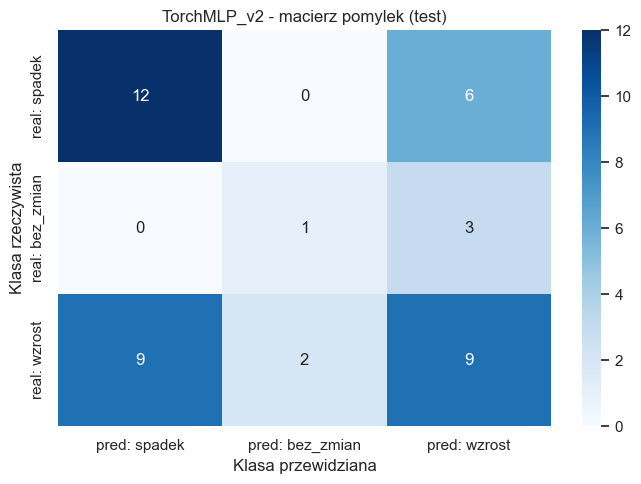

In [5]:
sel = cache[(float(best["neutral_band"]), str(best["lag_name"]))]
train_df, test_df, feat_cols = sel["train"], sel["test"], sel["feat_cols"]
X_train, y_train = train_df[feat_cols], train_df["y_code"].to_numpy(dtype=np.int64)
X_test, y_test = test_df[feat_cols], test_df["y_code"].to_numpy(dtype=np.int64)

dist = pd.DataFrame({
    "train_pct": (train_df["y"].value_counts(normalize=True) * 100).reindex(CLASS_ORDER).fillna(0).round(2),
    "test_pct": (test_df["y"].value_counts(normalize=True) * 100).reindex(CLASS_ORDER).fillna(0).round(2),
})
display(dist)

inner_val = max(30, min(70, int(len(train_df) * 0.12)))
tr_inner, va_inner = train_df.iloc[:-inner_val], train_df.iloc[-inner_val:]
bundle_inner = fit_torch(tr_inner[feat_cols], tr_inner["y_code"].to_numpy(), va_inner[feat_cols], va_inner["y_code"].to_numpy(), MODEL_CFG, seed=RANDOM_STATE, verbose=True)
final_epochs = max(30, int(bundle_inner["best_epoch"]))
print("final_epochs:", final_epochs)

bundle = fit_torch_full(X_train, y_train, MODEL_CFG, epochs=final_epochs, seed=RANDOM_STATE + 99)
pred_train = predict_torch(bundle, X_train)
pred_test = predict_torch(bundle, X_test)

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train.fillna(0), y_train)
pred_dummy = dummy.predict(X_test.fillna(0))

def row(name, split, yt, yp):
    return {
        "model": name,
        "split": split,
        "accuracy": accuracy_score(yt, yp),
        "balanced_accuracy": balanced_accuracy_score(yt, yp),
        "macro_f1": f1_score(yt, yp, average="macro", zero_division=0),
    }

metrics = pd.DataFrame([
    row("Dummy(most_frequent)", "test", y_test, pred_dummy),
    row("TorchMLP_v2", "train", y_train, pred_train),
    row("TorchMLP_v2", "test", y_test, pred_test),
])
display(metrics.round(4))

print("Raport klasyfikacji TorchMLP_v2 (test):")
print(classification_report(y_test, pred_test, labels=CLASS_CODE_ORDER, target_names=CLASS_ORDER, zero_division=0))

cm = confusion_matrix(y_test, pred_test, labels=CLASS_CODE_ORDER)
cm_df = pd.DataFrame(cm, index=[f"real: {c}" for c in CLASS_ORDER], columns=[f"pred: {c}" for c in CLASS_ORDER])
display(cm_df)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("TorchMLP_v2 - macierz pomylek (test)")
plt.xlabel("Klasa przewidziana")
plt.ylabel("Klasa rzeczywista")
plt.tight_layout()
plt.show()


In [6]:
results_path = output_dir / "stock_direction_v2_search_results.csv"
base_path = output_dir / "stock_direction_dataset_v2_base_best.csv"
lagged_path = output_dir / "stock_direction_dataset_v2_lagged_best.csv"
metrics_path = output_dir / "stock_direction_v2_metrics.csv"

results.to_csv(results_path, index=False)
sel["base"].to_csv(base_path, index=False)
sel["lagged"].to_csv(lagged_path, index=False)
metrics.to_csv(metrics_path, index=False)

print(results_path)
print(base_path)
print(lagged_path)
print(metrics_path)


..\data\equity_data\model_data\stock_direction_v2_search_results.csv
..\data\equity_data\model_data\stock_direction_dataset_v2_base_best.csv
..\data\equity_data\model_data\stock_direction_dataset_v2_lagged_best.csv
..\data\equity_data\model_data\stock_direction_v2_metrics.csv


## Notatki

- Ten notebook stroi `neutral_band` i lagi, ale trzyma stala architekture MLP.
- Jesli klasa `bez_zmian` dalej ma niski recall, pierwsza rzecz do dalszego tuningu to zakres neutralny.
- Kolejny krok: walk-forward na wielu oknach i porownanie z prostszymi modelami.
